<a href="https://colab.research.google.com/github/nahmed153/AR_Detection/blob/main/CODES/own_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AR vs non-AR (Binary Classification)

Custom CNN model

April 15th, 2026

It uses Pytorch and nn module which has all the functionalities to design a neural network

It makes use of two clases Dataloader and Dataset to incorporate MINI BATCH GRADIENT DESCENT (loading the data in batches/chunks) for parallel processing.

IMPORTANT NOTE:

It does not require the dataset to be split into two distinct folders (for binary classification). Instead it takes the datalabels for each image separately.

Users interested in running the code on other IDEs need to make a few modifications accordingly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from skimage import io

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader # Two classes Dataset and DataLoader are imported
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets, models, transforms

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
# Random seed is used for reproducibility (so that if the code is run again, it will produce the similar results)
torch.manual_seed(1)

In [ ]:
# print system versions

import sys
print("Python version:", sys.version)
import platform
print("Platform:", platform.platform())
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Torch version:", torch.__version__)


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
System: Linux
Release: 6.6.122+
Machine: x86_64
Processor: x86_64
Torch version: 2.11.0+cpu


1. DEFINING THE DATASET & DATALOADER

In [ ]:
# Transformations      (could be different for different pre-trained models)
custom_transform = transforms.Compose([
                  transforms.Resize((224, 224)),  # Resize to standard input size
                  transforms.ToTensor(),          # Convert to tensor and also scales automatically.
                  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                                   # most data works well once we normalize it.
                                   # mean and std of the RGB channels as already computed in the imagenet database.
])

In [ ]:
# Defining "customdataset" class
class MyCustomDataset(Dataset):   # class has to be inherited from nn module.
                                  # Dataset is a parent class in nn module.
  def __init__(self, csv_file, root_dir, transform):   # create our constructor

      self.root_dir = root_dir
      self.data = pd.read_csv(csv_file)
      self.transform = transform

  def __len__(self):
      return len(self.data)

  def __getitem__(self, index):

      # Ensure the image identifier is treated as a string and append '.jpg'
      image_id = str(self.data.iloc[index, 0])
      image_filename = image_id # Removed redundant '+ '.jpg''
      image_path = os.path.join(self.root_dir, image_filename)
      image = io.imread(image_path)     # This image command is from the PIL package
      print(image_path) #This line might cause the slow first epoch
      label = torch.tensor(int(self.data.iloc[index, 1]))  # Access the label using the column name instead of index

      # Convert image to RGB if it's grayscale (1D -> 3D)
      if image.ndim == 2:  # Check if image has only 2 dimensions (grayscale)
          image = np.stack((image,)*3, axis=-1)  # Convert to 3 channels (RGB)

      # Convert image to PIL Image and apply transforms
      image = Image.fromarray(image)  # Convert NumPy array to PIL Image
      image = self.transform(image)  # Apply your defined transforms

      return (image, label)

  def classes(self):
      return self.data.classes

In [ ]:
# Defining the directory paths
root_dir = "../content/drive/MyDrive/Northeast_AR_Dataset"
path_to_folder = "../content/drive/MyDrive/AR_Detection_Codes"     # path_to_folder was only needed to have access to the csv_file
csv_file = os.path.join(path_to_folder, "the_list.csv")
dataset = MyCustomDataset(csv_file, root_dir, transform=custom_transform)   # we can create an instance of this customdataset by a simple "dataset"

In [ ]:
# Tests to check
len(dataset)

21915

In [ ]:
# Extract labels from the dataset for stratification# Performing Stratified Split (It ensures similar proportions of each class in training and validation dataset as they were in the parent dataset)
from sklearn.model_selection import StratifiedShuffleSplit

# Extract labels from the dataset for stratification
labels = dataset.data.iloc[:, 1].to_numpy()

# Initialize StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform the split
# The split returns (train_index, val_index) for each split
for train_index, val_index in sss.split(np.zeros(len(labels)), labels):
    # Create training and validation subsets using torch.utils.data.Subset
    train_dataset = torch.utils.data.Subset(dataset, train_index)
    val_dataset = torch.utils.data.Subset(dataset, val_index)

# Print the lengths of the new datasets to confirm the split
print(f"Stratified Training dataset size: {len(train_dataset)}")
print(f"Stratified Validation dataset size: {len(val_dataset)}")

Stratified Training dataset size: 17532
Stratified Validation dataset size: 4383


2. DATALOADER CLASS

In [ ]:
# Defining the DataLoader class
train_loader = DataLoader(dataset= train_dataset, batch_size=128, shuffle=True, pin_memory=True)  # We are creating an object train_loader which is an object of DataLoader class.
                                                              # 1. we have to send the object i.e. train_dataset or the dataset directly (if we didn't wanted the train/test split)
                                                              # 2. we have to define the batch size here
                                                              # 3. we have to shuffle and that is required
                                                              # If the shuffle is False then batches will be made in order which we dont want.
val_loader = DataLoader(dataset= val_dataset, batch_size=128, shuffle=False, pin_memory=True)

3. CREATING A PYTOCH MODEL

In [ ]:
# Move to GPU
# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #added
print(f"Using device: {device}") #added

Using device: cpu


In [ ]:
# find total number of batches
total_batches = len(train_loader)
print(f"Total number of batches in the training loader: {total_batches}")

total_batches_val = len(val_loader)
print(f"Total number of batches in the validation loader: {total_batches_val}")

Total number of batches in the training loader: 137
Total number of batches in the validation loader: 35


DEFINING THE MODEL

TRAINING PIPELINE

In [ ]:
class MySimpleNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),  # input_features here ensure that RGB=3 and grayscale=1 are taken care of
                                                                       # 32 is the no. of filters used in this layer.
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),
    ) # Added missing closing parenthesis

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32 * 112 * 112, 128), # Corrected input size: 32 channels * 112 height * 112 width
        nn.ReLU(),
        nn.Dropout(0.31641967317788267),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.31641967317788267),

        nn.Linear(64, 2)
    )

  def forward(self, x):
    x = self.features(x)    # Becauase we have created sequential containers
    x = self.classifier(x)
    return x

# Re-defining device, learning_rate, epochs (already defined but for clarity)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.00010358008219078031
#learning_rate = 0.001
epochs = 25 # Using 'epochs' consistently

# Re-instantiate the model and move it to the device
model = MySimpleNN(3)
model.to(device)

# Re-define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.05917366481516203) # Changed to Adam as per previous output

# Initialize lists to store metrics
train_losses = []
train_accuracies = []
val_losses = [] # Initialize val_losses list
val_accuracies = []

# Define loop
for epoch in range(epochs):
  model.train() # Set model to training mode
  total_train_loss = 0.0
  total_train_correct = 0
  total_train_samples = 0

  for batch_idx, (batch_features, batch_labels) in enumerate(train_loader):

    # Move batch_features and batch_labels to the device
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    # Cast batch_features to float32
    batch_features = batch_features.type(torch.float32)

    # Define forward pass
    outputs = model(batch_features)

    # clear gradients
    optimizer.zero_grad()

    # Loss Calculate
    loss = criterion(outputs, batch_labels)

    # Backward pass
    loss.backward()

    # Parameters update
    optimizer.step()

    total_train_loss += loss.item()
    _, prediction1 = torch.max(outputs.data, 1)
    total_train_correct += (prediction1 == batch_labels).sum().item()
    total_train_samples += batch_labels.size(0)

    print(f'Epoch: {epoch+1}, Batch: {batch_idx+1}/{len(train_loader)}, Batch Loss: {loss.item():.4f}')

  # Updating the Tracking lists/variables after each epoch
  avg_train_loss = total_train_loss / len(train_loader)
  train_losses.append(avg_train_loss) # Save training loss
  train_accuracy = total_train_correct / total_train_samples
  train_accuracies.append(train_accuracy)

  print(f'Epoch: {epoch+1}, Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')

  # Validation phase
  model.eval() # Set model to evaluation mode

  total_val_loss = 0.0
  total_val_correct = 0
  total_val_samples = 0

  with torch.no_grad():
    for batch_features_val, batch_labels_val in val_loader: # Use val_loader for validation
      batch_features_val = batch_features_val.to(device)
      batch_labels_val = batch_labels_val.to(device)
      batch_features_val = batch_features_val.type(torch.float32)

      outputs_val = model(batch_features_val)
      val_loss = criterion(outputs_val, batch_labels_val) # Calculate validation loss
      total_val_loss += val_loss.item()

      _, prediction2 = torch.max(outputs_val.data, 1)
      total_val_samples += batch_labels_val.size(0)
      total_val_correct += (prediction2 == batch_labels_val).sum().item()

  # Updating the Tracking lists/variables after each epoch
  avg_val_loss = total_val_loss / len(val_loader)
  val_losses.append(avg_val_loss)
  val_accuracy = total_val_correct / total_val_samples
  val_accuracies.append(val_accuracy)

  print(f'Epoch: {epoch+1}, Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

# The lists train_losses, train_accuracies, val_losses, and val_accuracies are now populated and available in the kernel.
# You can access them in subsequent cells, for example, to plot them.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


../content/drive/MyDrive/Northeast_AR_Dataset/22350.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/25860.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/42624.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/32164.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/42614.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/1246.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/25166.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/35850.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/26724.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/15742.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/36468.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/43464.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/43076.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/6794.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/28382.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/35492.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/24902.jpg
../content/drive/MyDrive/Northeast_AR_Dataset/2971

In [ ]:
# Don't run it (unless you want to increase the number of conv_blocks)
class MySimpleNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()
    self.features = nn.Sequential(
        # Block 1
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 2
        nn.Conv2d(32, 64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 3
        nn.Conv2d(64, 128, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 4
        nn.Conv2d(128, 256, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(256),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Block 5
        nn.Conv2d(256, 512, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(512),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512 * 7 * 7, 128), # Adjusted input size for 5 conv blocks
        nn.ReLU(),
        nn.Dropout(0.20013274866014355),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.20013274866014355),

        nn.Linear(64, 2)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

# Re-defining device, learning_rate, epochs (already defined but for clarity)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.001
epochs = 15 # Using 'epochs' consistently

# Re-instantiate the model and move it to the device
model = MySimpleNN(3)
model.to(device)

# Re-define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.05317843131354303)

# Initialize lists to store metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Define loop
for epoch in range(epochs):
  model.train() # Set model to training mode
  total_train_loss = 0.0
  total_train_correct = 0
  total_train_samples = 0

  for batch_idx, (batch_features, batch_labels) in enumerate(train_loader):

    # Move batch_features and batch_labels to the device
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    # Cast batch_features to float32
    batch_features = batch_features.type(torch.float32)

    # Define forward pass
    outputs = model(batch_features)

    # clear gradients
    optimizer.zero_grad()

    # Loss Calculate
    loss = criterion(outputs, batch_labels)

    # Backward pass
    loss.backward()

    # Parameters update
    optimizer.step()

    total_train_loss += loss.item()
    _, prediction1 = torch.max(outputs.data, 1)
    total_train_correct += (prediction1 == batch_labels).sum().item()
    total_train_samples += batch_labels.size(0)

    print(f'Epoch: {epoch+1}, Batch: {batch_idx+1}/{len(train_loader)}, Batch Loss: {loss.item():.4f}')

  # Updating the Tracking lists/variables after each epoch
  avg_train_loss = total_train_loss / len(train_loader)
  train_losses.append(avg_train_loss) # Save training loss
  train_accuracy = total_train_correct / total_train_samples
  train_accuracies.append(train_accuracy)

  print(f'Epoch: {epoch+1}, Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')

  # Validation phase
  model.eval() # Set model to evaluation mode

  total_val_loss = 0.0
  total_val_correct = 0
  total_val_samples = 0

  with torch.no_grad():
    for batch_features_val, batch_labels_val in val_loader:
      batch_features_val = batch_features_val.to(device)
      batch_labels_val = batch_labels_val.to(device)
      batch_features_val = batch_features_val.type(torch.float32)

      outputs_val = model(batch_features_val)
      val_loss = criterion(outputs_val, batch_labels_val)
      total_val_loss += val_loss.item()

      _, prediction2 = torch.max(outputs_val.data, 1)
      total_val_samples += batch_labels_val.size(0)
      total_val_correct += (prediction2 == batch_labels_val).sum().item()

  # Updating the Tracking lists/variables after each epoch
  avg_val_loss = total_val_loss / len(val_loader)
  val_losses.append(avg_val_loss)
  val_accuracy = total_val_correct / total_val_samples
  val_accuracies.append(val_accuracy)

  print(f'Epoch: {epoch+1}, Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')


In [ ]:
model = MySimpleNN(3) # Instantiate the model
# Count the number of Conv2d layers, which represent convolution blocks
conv_blocks_count = sum(1 for module in model.features if isinstance(module, torch.nn.Conv2d))
print(f"Number of convolution blocks in the MySimpleNN model: {conv_blocks_count}")

Number of convolution blocks in the MySimpleNN model: 1


In [ ]:
# prompt: print train_losses, train accuracies, val_losses

print("Train Losses:", train_losses)
print("Train Accuracies:", train_accuracies)
print("Validation Losses:", val_losses)
print("Validation Accuracies:", val_accuracies)

Train Losses: [0.7416063009822456, 0.5818445963146043, 0.563986663618227, 0.5534771750443173, 0.5496219359610203, 0.5434516444258446, 0.5396913625028011, 0.5351551940841396, 0.5346513179531933, 0.5294851641150287, 0.5262469418727569, 0.5265049786463271, 0.5264619353913913, 0.5200418436179196, 0.5176747143268585, 0.5171496185073017, 0.5180847805781956, 0.5194908321773919, 0.5167717566020298, 0.5172960399276149, 0.5161053544848505, 0.5163475383807273, 0.515387490718034, 0.5146460535317442, 0.5089108735105418]
Train Accuracies: [0.6646703171343828, 0.7023157654574492, 0.715605749486653, 0.7186858316221766, 0.7262149212867899, 0.7293520419803787, 0.7333447410449464, 0.7323180469997719, 0.73642482318047, 0.7373944786675792, 0.7393908281998631, 0.7367670545288615, 0.7388774811772758, 0.74435318275154, 0.7481177275838466, 0.7469769564225417, 0.7448094912160621, 0.7440679899612138, 0.7482318046999772, 0.7482888432580425, 0.7477754962354551, 0.7487451517225645, 0.7462924937257586, 0.75011407711

In [ ]:
val_accuracies

[0.7230207620351358,
 0.73077800593201,
 0.7339721651836641,
 0.7453798767967146,
 0.7437827971708875,
 0.7417294090805384,
 0.7476614191193247,
 0.7497148072096738,
 0.7545060460871549,
 0.7501711156741958,
 0.7433264887063655,
 0.7403604836869724,
 0.7510837326032398,
 0.7469769564225417,
 0.7531371206935888,
 0.7542778918548939,
 0.7449235683321925,
 0.7542778918548939,
 0.7618069815195072,
 0.7499429614419347,
 0.7474332648870636,
 0.7492584987451517,
 0.7490303445128907,
 0.7506274241387177,
 0.755418663016199]

In [ ]:
train_losses

[0.7416063009822456,
 0.5818445963146043,
 0.563986663618227,
 0.5534771750443173,
 0.5496219359610203,
 0.5434516444258446,
 0.5396913625028011,
 0.5351551940841396,
 0.5346513179531933,
 0.5294851641150287,
 0.5262469418727569,
 0.5265049786463271,
 0.5264619353913913,
 0.5200418436179196,
 0.5176747143268585,
 0.5171496185073017,
 0.5180847805781956,
 0.5194908321773919,
 0.5167717566020298,
 0.5172960399276149,
 0.5161053544848505,
 0.5163475383807273,
 0.515387490718034,
 0.5146460535317442,
 0.5089108735105418]

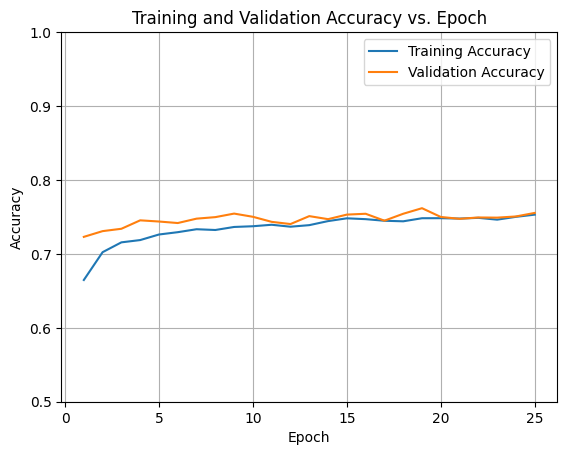

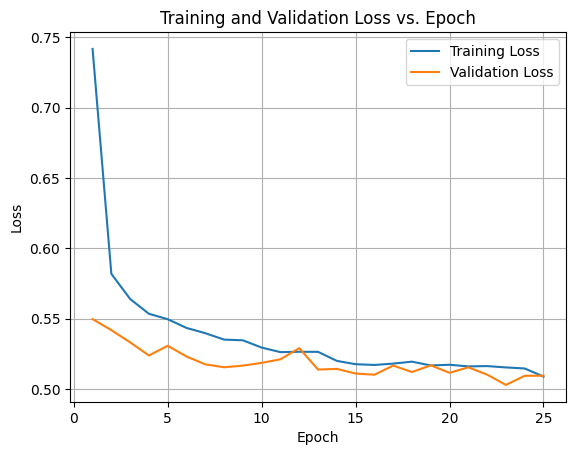

In [ ]:
# prompt: plotting training and validation accuracies using matplot

# Get the actual number of epochs recorded in the lists
actual_epochs = len(train_accuracies)

# Plotting the training and validation accuracies
#plt.figure(figsize=(10, 6))
plt.plot(range(1, actual_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, actual_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs. Epoch')
plt.legend()
plt.grid(True)
plt.ylim(0.5, 1) # Set y-axis limits from 0.5 to 1
plt.show()

# Plotting the training and validation losses
#plt.figure(figsize=(10, 6))
plt.plot(range(1, actual_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, actual_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs. Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# prompt: create confusion matrix for final epoch

from sklearn.metrics import confusion_matrix

# Get the true labels and predictions for the validation set
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device=device)
        labels = labels.to(device=device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Define class names (assuming 0 and 1 based on the context)
class_names = ['Non-AR', 'AR']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
#plt.title('Confusion Matrix for Final Epoch')
plt.show()

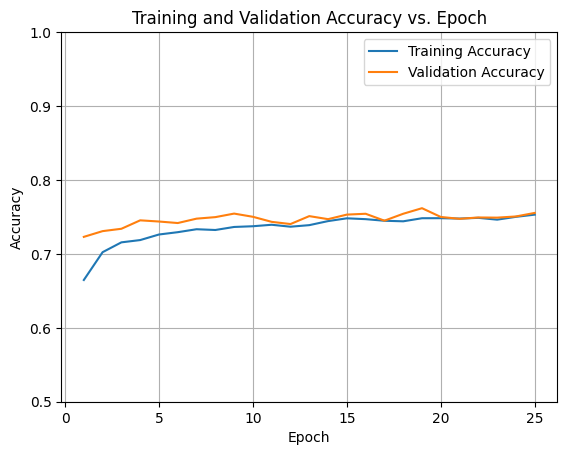

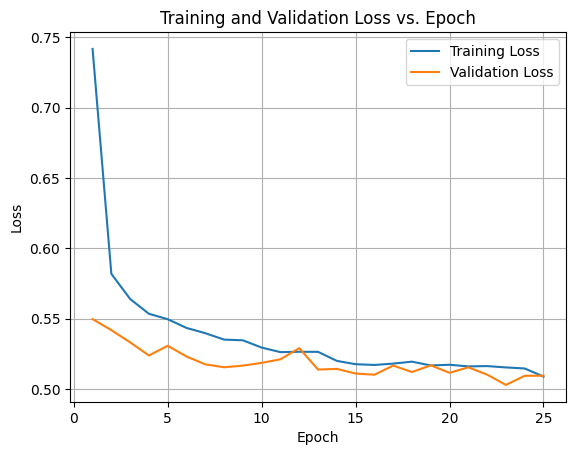

In [ ]:
import matplotlib.pyplot as plt

# Plotting the training and validation accuracies
#plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs. Epoch')
plt.legend()
plt.grid(True)
plt.ylim(0.5, 1) # Set y-axis limits from 0.5 to 1
plt.show()

# Plotting the training and validation losses
#plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs. Epoch')
plt.legend()
plt.grid(True)
plt.show()

../content/drive/MyDrive/ELEG845/Mar2025/try3/36698.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/15910.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/30946.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/4712.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/33514.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/27926.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/2464.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/37866.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/4158.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/34826.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/18690.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/14152.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/3546.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/27976.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/13842.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/30270.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/31620.jpg
../content/drive/MyDrive/ELEG845/Mar2025/try3/9328.j

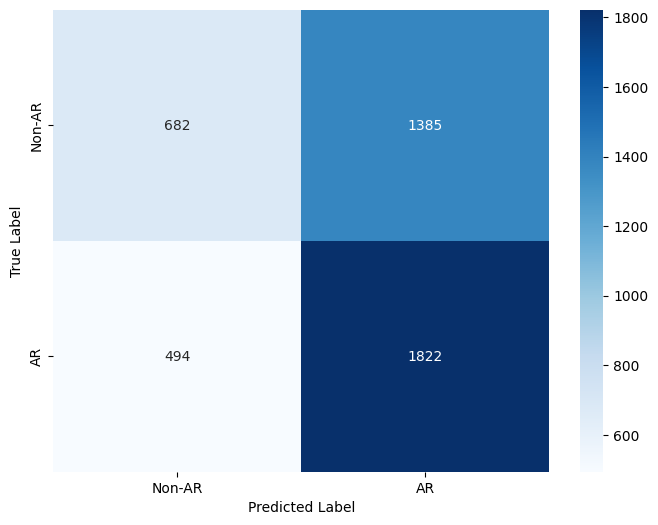

In [ ]:
# prompt: create confusion matrix of final epoch

from sklearn.metrics import confusion_matrix

# Get the true labels and predictions for the validation set
all_labels = []
all_predictions = []

# Ensure the model is on the correct device before evaluation
model.to(device)

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device=device)
        labels = labels.to(device=device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Define class names (assuming 0 and 1 based on the context)
class_names = ['Non-AR', 'AR']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
#plt.title('Confusion Matrix for Epoch')
plt.show()